# 01 - The Taste Engine, end to end

**A five-minute product tour of the interpretable playlist recommender.**

Every recommender in this project answers *"what should play next?"*. Only one of
them can also answer *"**why**?"* - the **Taste Engine**. This notebook builds a
small synthetic Spotify-style corpus, fits a couple of models live, and then walks
the Taste Engine through its whole story for a single listener:

1. it **learns** a taste vector from what the listener actually played,
2. it lets the listener **state** a preference in plain English and blends the two,
3. it distills the listener into a few **named flavor clusters**, and
4. it **explains every recommendation** in human terms.

Everything here is seeded and runs in well under a minute. The scale is deliberately
tiny (1,500 playlists / 1,200 tracks) so the notebook is fast; the full-scale numbers
live in `RESULTS.md` and `ABLATIONS.md`.

> **Scope.** This runs on the built-in *synthetic* Million-Playlist-Dataset generator,
> which ships interpretable per-track audio axes (tempo, energy, valence, ...). The real
> MPD has no audio features, so on real data you attach them via a CSV - the engine then
> runs identically.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
VIZ = os.path.join("..", "visualizations")
os.makedirs(VIZ, exist_ok=True)

from playlistcont.data.synthetic import make_synthetic
from playlistcont.data.schema import AXES, SCALAR_AXES, GENRES
from playlistcont.models.itemcf import ItemCFRecommender
from playlistcont.models.mf import ALSRecommender
from playlistcont.models.taste_engine import TasteEngine, parse_stated

t0 = time.time()
print("imports ready")

imports ready


## 1. Generate a small synthetic MPD

The generator plants ten latent **taste archetypes** (e.g. *sad slow country*, *gym
rap*, *edm rave*). Each track gets a home archetype, interpretable audio axes drawn
around that archetype's profile, and a power-law popularity. Each playlist mixes a
primary archetype (80%) with a secondary one and a little global popularity, and gets
a title drawn from its archetype's vocabulary. That structure is exactly what gives
collaborative filtering, the title model, and the Taste Engine genuine signal to
recover.

In [2]:
ds = make_synthetic(n_playlists=1500, n_tracks=1200, seed=0)
print(f"Synthetic MPD: {ds.n_playlists} playlists, {ds.n_tracks} tracks, "
      f"{len(AXES)} interpretable axes per track")
print("axes:", AXES)

# a peek at three playlists and their titles
for pl in ds.playlists[:3]:
    print(f"  pid={pl.pid:4d}  title={pl.name!r:32s}  {len(pl.tracks)} tracks")

Synthetic MPD: 1500 playlists, 1200 tracks, 15 interpretable axes per track
axes: ['tempo', 'energy', 'valence', 'acousticness', 'lyrical_depth', 'genre:country', 'genre:rap', 'genre:indie', 'genre:pop', 'genre:rock', 'genre:electronic', 'genre:folk', 'genre:metal', 'genre:rnb', 'genre:jazz']
  pid=   0  title='bedroom'                         43 tracks
  pid=   1  title='late night bedroom songs'        23 tracks
  pid=   2  title='headbang'                        36 tracks


## 2. Fit two black-box models live

Item-item collaborative filtering (co-occurrence neighbourhoods) and ALS matrix
factorization - the two strongest single models in the full study - fit in a second or
two at this scale. They return good tracks, but they cannot tell you *why* a track was
chosen.

In [3]:
cf = ItemCFRecommender().fit(ds)
als = ALSRecommender(factors=32, iterations=5).fit(ds)

# pick a clearly-themed 'sad slow country' playlist to use as our listener
sad_words = {"heartbreak", "whiskey", "lonely", "cry", "country", "tears", "back roads"}
listener = next(pl for pl in ds.playlists
                if any(w in (pl.name or "") for w in sad_words) and len(pl.tracks) >= 15)
seed = listener.tracks[:8]        # what we let the models see
held = set(listener.tracks[8:])   # what we hope to recover
print(f"Listener playlist: title={listener.name!r}, {len(listener.tracks)} tracks")
print(f"Showing the models the first {len(seed)} tracks, holding out {len(held)}.\n")

for name, model in [("item_cf", cf), ("als", als)]:
    recs = model.recommend(seed, listener.name, k=5)
    hits = sum(r in held for r in recs)
    print(f"{name:8s} top-5: {recs}   ({hits}/5 are held-out ground truth)")

Listener playlist: title='tears', 19 tracks
Showing the models the first 8 tracks, holding out 11.

item_cf  top-5: ['spotify:track:s001131', 'spotify:track:s000097', 'spotify:track:s000415', 'spotify:track:s000795', 'spotify:track:s000484']   (3/5 are held-out ground truth)
als      top-5: ['spotify:track:s001131', 'spotify:track:s000097', 'spotify:track:s000415', 'spotify:track:s000795', 'spotify:track:s000484']   (3/5 are held-out ground truth)


/usr/local/lib/python3.11/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


## 3. The Taste Engine LEARNS a preference vector

The Taste Engine models the listener as a **preference vector over interpretable axes**.
The *learned* vector combines two signals from the listener's own tracks: the centroid
direction (how far their tracks sit from the global average on each standardized axis)
and logistic-regression coefficients of an *"is this track yours?"* classifier. The
coefficients **are** the taste: negative `valence` means they lean sad, positive
`lyrical_depth` means they value meaning.

For our *sad slow country* listener we expect exactly that signature to fall out - with
no hand-labelling.

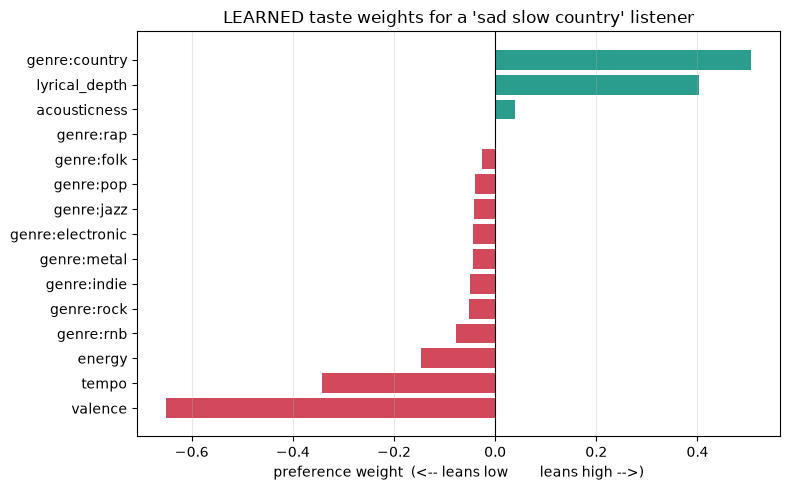

Top discriminating axes (|weight|):
  valence          -0.650   leans low/sad/slow
  genre:country    +0.505   leans high
  lyrical_depth    +0.403   leans high
  tempo            -0.342   leans low/sad/slow
  energy           -0.147   leans low/sad/slow


In [4]:
te = TasteEngine(trust=0.4, n_flavors=3).fit(ds)
learned = te.learn_weights(seed)

order = np.argsort(learned)   # most negative -> most positive
labels = [AXES[i] for i in order]
vals = learned[order]
colors = ["#d1495b" if v < 0 else "#2a9d8f" for v in vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, vals, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_title("LEARNED taste weights for a 'sad slow country' listener")
ax.set_xlabel("preference weight  (<-- leans low        leans high -->)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(VIZ, "nb_taste_learned_weights.png"), dpi=110)
plt.show()

top = np.argsort(-np.abs(learned))[:5]
print("Top discriminating axes (|weight|):")
for i in top:
    lean = "leans low/sad/slow" if learned[i] < 0 else "leans high"
    print(f"  {AXES[i]:16s} {learned[i]:+.3f}   {lean}")

The engine recovered the archetype on its own: **valence negative** (sad),
**country positive**, **lyrical_depth positive** (values meaning), **tempo negative**
(slow). That vector is the whole interpretability story - it is not a post-hoc
explanation bolted onto a black box, it is the actual scoring model.

## 4. STATED preference + the `trust` blend

A listener can also just *say* what they want. A small lexicon turns
`"slow sad country with deep lyrics"` into signed axis emphases, and the `trust`
parameter decides how much to believe what they **said** over what they **did**:

$$w \;=\; \tau\, \hat{w}_{\text{stated}} \;+\; (1-\tau)\, \hat{w}_{\text{learned}}$$

`trust` is the safety valve: when a stated preference is honest it helps a little;
when it is wrong, dialing `trust` down falls back on behaviour. (The adversarial
`trust` sweep in `ABLATIONS.md` quantifies this cliff.)

In [5]:
stated_text = "slow sad country with deep lyrics"
stated = parse_stated(stated_text)
print(f"Parsed {stated_text!r} into axis emphases:")
for i in np.argsort(-np.abs(stated))[:5]:
    if abs(stated[i]) > 0:
        print(f"  {AXES[i]:16s} {stated[i]:+.2f}")

blend = te.blend(stated, learned)
print(f"\nBlended vector at trust={te.trust}: "
      f"top axes {[AXES[i] for i in np.argsort(-np.abs(blend))[:4]]}")

Parsed 'slow sad country with deep lyrics' into axis emphases:
  tempo            -1.00
  valence          -1.00
  genre:country    +1.00
  lyrical_depth    +0.90

Blended vector at trust=0.4: top axes ['valence', 'genre:country', 'lyrical_depth', 'tempo']


## 5. Named FLAVOR clusters

k-means on the listener's tracks in raw axis space, with each centroid rendered into
English by a template. This is how the product would show a user *"here are the moods
we found in your library."*

In [6]:
flavors = te.flavor_clusters(seed)
print("FLAVOR CLUSTERS (k-means on the listener's tracks):")
for f in flavors:
    print(f"  - {f.name:48s}  (share {f.share:.0%})")

FLAVOR CLUSTERS (k-means on the listener's tracks):
  - slow, sad, acoustic country with deep lyrics      (share 50%)
  - slow, sad, acoustic country with deep lyrics      (share 38%)
  - slow, sad country with deep lyrics                (share 12%)


## 6. Recommendations, each with an explanation

Finally the payoff: the engine scores candidates as **weighted axis-match +
co-occurrence**, and every recommendation carries a plain-English justification - which
flavor it matched, the load-bearing axis values, how many of your seeds it co-occurs
with, and whether it shares an artist.

In [7]:
recs = te.recommend(seed, listener.name, k=6, stated=stated_text)
print("TOP RECOMMENDATIONS WITH EXPLANATIONS (stated + learned blend)\n")
for r in recs:
    ex = te.explain(r, seed, weights=blend, flavors=flavors)
    hit = "  <-- held-out ground truth" if r in held else ""
    print(f"  {r}{hit}")
    print(f"     {ex.text()}")
    if ex.axis_scores:
        contrib = ", ".join(f"{a} {v:+.2f}" for a, v in ex.axis_scores.items())
        print(f"     load-bearing axes: {contrib}")
    print()

TOP RECOMMENDATIONS WITH EXPLANATIONS (stated + learned blend)

  spotify:track:s001131  <-- held-out ground truth
     recommended because: matches your 'slow, sad, acoustic country with deep lyrics' flavor (valence 0.23, tempo 0.18); co-occurs with 8 of your seed tracks
     load-bearing axes: genre:country +1.47, valence +0.94, tempo +0.77

  spotify:track:s000097  <-- held-out ground truth
     recommended because: matches your 'slow, sad, acoustic country with deep lyrics' flavor (valence 0.22, tempo 0.17); co-occurs with 8 of your seed tracks
     load-bearing axes: genre:country +1.45, valence +0.96, tempo +0.79

  spotify:track:s000795
     recommended because: matches your 'slow, sad, acoustic country with deep lyrics' flavor (valence 0.25, tempo 0.18); co-occurs with 8 of your seed tracks
     load-bearing axes: genre:country +1.77, valence +0.87, tempo +0.78

  spotify:track:s000415
     recommended because: matches your 'slow, sad, acoustic country with deep lyrics' flavor 

## 7. The point: control the recommendations by changing the words

Because the preference is an explicit vector, the listener can *steer* it. Ask for the
opposite mood - `"fast happy party"` - and, at high `trust`, the same engine and the
same seed produce a completely different, upbeat list. No other model in the catalogue
can be driven this way.

In [8]:
te_hi = TasteEngine(trust=0.95, n_flavors=3).fit(ds)
for phrase in ["slow sad country with deep lyrics", "fast happy party hype"]:
    recs = te_hi.recommend(seed, listener.name, k=3, stated=phrase)
    w = te_hi.blend(parse_stated(phrase), te_hi.learn_weights(seed))
    val_i, tempo_i = AXES.index("valence"), AXES.index("tempo")
    print(f"stated={phrase!r:38s}  ->  blended valence {w[val_i]:+.2f}, tempo {w[tempo_i]:+.2f}")
    for r in recs:
        x = te_hi.X[te_hi.index.uri_to_id[r]]
        print(f"     {r}   (this track: valence {x[2]:.2f}, tempo {x[0]:.2f})")
    print()
print(f"\nNotebook ran in {time.time()-t0:.1f}s")

stated='slow sad country with deep lyrics'     ->  blended valence -0.51, tempo -0.51
     spotify:track:s000097   (this track: valence 0.22, tempo 0.17)
     spotify:track:s001131   (this track: valence 0.23, tempo 0.18)
     spotify:track:s000795   (this track: valence 0.25, tempo 0.18)

stated='fast happy party hype'                 ->  blended valence +0.40, tempo +0.71
     spotify:track:s000216   (this track: valence 0.93, tempo 1.00)
     spotify:track:s000457   (this track: valence 0.88, tempo 0.97)
     spotify:track:s000340   (this track: valence 0.76, tempo 0.99)


Notebook ran in 1.3s


## Takeaway

The Taste Engine trades a little raw recall (it sits in the CF pack at ~0.30 R-precision
on the full study) for something no black box offers: a preference it **learned** and can
**show you**, a preference you can **state and steer**, flavor clusters that **name** your
moods, and an **explanation** on every single recommendation. That is the difference
between a recommender and a recommender a person can trust.

See **`02_experiments.ipynb`** for the full quantitative comparison across all seven
models and ten scenarios, and **`REPORT.md`** for the research write-up.